Importing libraries

In [307]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import itertools
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import precision_score, recall_score
from sklearn.mixture import BayesianGaussianMixture
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve


RANDOMSTATE = 42

# import keras
# from keras import layers

Importing data data, assigning it to a dataframe. Converting the timestamp column to datetime format, dropping the added indexing "NUM". Removing sensors with a high degree of NaN values (above 5%), stripping to remove strings, and filling in NaN values using forward fill. Lastly removing highly linearly correlated sensors.

In [308]:
df = pd.read_csv("C:/Users/andsa/Documents/ML/MLing/dataset/sensor.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])
df.drop(columns=["num"], axis=1,  inplace=True)
df.drop(columns=["sensor_15", "sensor_50", "sensor_51"], axis=1,  inplace=True)
df.columns.str.strip()
df.fillna(method='ffill', inplace=True)


# dropping columns with high linear correlation 
df.drop(columns=["sensor_19", "sensor_18", "sensor_21", "sensor_23", "sensor_24"], axis=1,  inplace=True)

Assessing the dataset.

In [309]:
machine_status = df['machine_status'].value_counts()
normal = machine_status[0]
recovering = machine_status[1]
broken = machine_status[2]
tot = normal + recovering + broken

normal_part = np.round(normal / tot, 4)
recovering_part = np.round(recovering / tot, 4)
broken_part = np.round(broken / tot, 4)
recovering_broken_part = np.round((recovering + broken) / tot, 4)

print(f'Normal instances: {normal}\nRecovering: {recovering}\nBroken: {broken}')
print(f'Ammount of normal of tot: {normal_part}\nAmmount of recovering of tot: {recovering_part}\nAmmount of broken of tot: {broken_part}\nAmmount of both recovering and broken of tot: {recovering_broken_part}')

Normal instances: 205836
Recovering: 14477
Broken: 7
Ammount of normal of tot: 0.9343
Ammount of recovering of tot: 0.0657
Ammount of broken of tot: 0.0
Ammount of both recovering and broken of tot: 0.0657


Assigning data to training and testing, creating X_train for training the model, X_test to get predictions from the model, and y_test for assessing the performance of the model using the labels.

In [310]:
# assigning train to the first 60%, and test to the remaining 40%
last_40percent = round(len(df) - len(df)*.4)
train = df.iloc[ :last_40percent, :]
test = df.iloc[last_40percent: ,:]
y_train = train['machine_status']

X_cols = train.iloc[ : , 1:-1].columns
X_train = train.iloc[:,1:-1].copy()


X_cols = test.iloc[ : , 1:-1].columns
X_test = test.iloc[:,1:-1].copy()
y_test = test['machine_status']

Looking at the distribution of both the training data, and test data. There is a large discrepancy between the status values. With NORMAL dominating, and recovering + broken not well reprecented. 

In [311]:
print("Distribution for the training data")
machine_status_train = y_train.value_counts()
normal_train = machine_status_train[0]
recovering_train = machine_status_train[1]
broken_train = machine_status_train[2]
tot_train = normal_train + recovering_train + broken_train

normal_part_train = np.round(normal_train / tot_train, 4)
recovering_part_train = np.round(recovering_train / tot_train, 4)
broken_part_train = np.round(broken_train / tot_train, 4)
recovering_broken_part_train = np.round((recovering_train + broken_train) / tot, 4)

print(f'Normal instances: {normal_train}\nRecovering: {recovering_train}\nBroken: {broken_train}')
print(f'Ammount of normal of tot: {normal_part_train}\nAmmount of recovering of tot: {recovering_part_train}\nAmmount of broken of tot: {broken_part_train}\nAmmount of both recovering and broken of tot: {recovering_broken_part_train}\n')


print()
print("Distribution for the test data")
machine_status_test = y_test.value_counts()
normal_test = machine_status_test[0]
recovering_test = machine_status_test[1]
broken_test = machine_status_test[2]
tot_test = normal_test + recovering_test + broken_test

normal_part_test = np.round(normal_test / tot_test, 4)
recovering_part_test = np.round(recovering_test / tot_test, 4)
broken_part_test = np.round(broken_test / tot_test, 4)
recovering_broken_part_test = np.round((recovering_test + broken_test) / tot, 4)

print(f'Normal instances: {normal_test}\nRecovering: {recovering_test}\nBroken: {broken_test}')
print(f'Ammount of normal of tot: {normal_part_test}\nAmmount of recovering of tot: {recovering_part_test}\nAmmount of broken of tot: {broken_part_test}\nAmmount of both recovering and broken of tot: {recovering_broken_part_test}\n')


Distribution for the training data
Normal instances: 122065
Recovering: 10122
Broken: 5
Ammount of normal of tot: 0.9234
Ammount of recovering of tot: 0.0766
Ammount of broken of tot: 0.0
Ammount of both recovering and broken of tot: 0.046


Distribution for the test data
Normal instances: 83771
Recovering: 4355
Broken: 2
Ammount of normal of tot: 0.9506
Ammount of recovering of tot: 0.0494
Ammount of broken of tot: 0.0
Ammount of both recovering and broken of tot: 0.0198



Scaling the train and testdata using standardscaler. Also doing PCA as to reduce the complexity of the data. 

In [312]:
# scaling and reducing complexity
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


pca = PCA(n_components = 0.95, svd_solver = 'full', random_state = RANDOMSTATE )
X_train_PCA = pca.fit_transform(X_train_scaled)
X_test_PCA = pca.transform(X_test_scaled)

print(f'X_train_PCA shape: {X_train_PCA.shape}\nX_test_PCA shape: {X_test_PCA.shape}')


X_train_PCA shape: (132192, 20)
X_test_PCA shape: (88128, 20)


In [313]:
# time_data = df['timestamp']

# def measurments_per_day(data):
#     measurements_per_day = data.dt.date.value_counts().sort_index()
#     day_1 = measurements_per_day[0]
#     wrong = 0

#     for measurments in measurements_per_day:
#         if measurments != day_1:
#             wrong+= 1
    
#     if wrong == 0:
#         print(f'All days have the same ammount of measurments: {day_1} ')
#     else:
#         print(f'All days do not have the same ammount of measurments')

# measurments_per_day(time_data)
# num_days = time_data.dt.date.nunique()
# print(f"Number of days: {num_days}")

Creating the Bayesian Gaussian Mixture model (BGM model), testing different hyperparameters, fitting the model to the training data, and using it to get predictions on the test data. 

In [335]:
# Create and fit the Bayesian Gaussian Mixture model
# bgm = BayesianGaussianMixture(n_components=10, n_init=10, random_state=42)
# bgm = BayesianGaussianMixture(n_components=3, covariance_type='diag', weight_concentration_prior_type='dirichlet_process', weight_concentration_prior = 0.01, init_params='kmeans', random_state=RANDOMSTATE)
bgm = BayesianGaussianMixture(n_components = 3, covariance_type = 'diag', weight_concentration_prior_type = 'dirichlet_process', weight_concentration_prior = 0.1, init_params = 'kmeans', random_state = RANDOMSTATE)

bgm.fit(X_train_PCA)
y_pred = bgm.predict(X_test_PCA)


Looking at the wrights of the model, as well as the elements and count of both y_pred and y_test. Seeing that the model only predicts NORMAL and RECOVERING, and comparing the number of predictions to the labels. 

In [336]:
# Check the learned weights
print(f'Component weights from the bgm model: {bgm.weights_.round(2)}\n')


counter_pred = Counter(y_pred)
print(f'Unique elements y_pred: {list(counter_pred.keys())}')
print(f'Counts: {list(counter_pred.values())}\n')


counter_test = Counter(y_test)
print(f'Unique elements y_test: {list(counter_test.keys())}')
print(f'Counts: {list(counter_test.values())}\n')

y_test_copy = y_test.copy()


Component weights from the bgm model: [0.63 0.25 0.12]

Unique elements y_pred: [1, 0]
Counts: [67445, 20683]

Unique elements y_test: ['RECOVERING', 'NORMAL', 'BROKEN']
Counts: [4355, 83771, 2]



Gathering both RECOVERING and BROKEN into the same class -> FAULTY.

In [337]:
# Replace values
y_test_copy.replace({"RECOVERING": "FAULTY", "BROKEN": "FAULTY"}, inplace=True)

# Check the new distribution
print(y_test_copy.value_counts())

NORMAL    83771
FAULTY     4357
Name: machine_status, dtype: int64


Using an encoder to get the y_test data on the correct form, with FAULTY and NORMAL represented by numerical values, 0 for FAULTY, and 1 for NORMAL.

In [338]:
# Initialize the encoder
label_encoder = LabelEncoder()

# Fit and transform labels
y_test_encoded = label_encoder.fit_transform(y_test_copy)

# Check mapping
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

counter_test_encoded = Counter(y_test_encoded)
print(f'\nUnique elements y_test_encoded: {list(counter_test_encoded.keys())}')
print(f'Counts: {list(counter_test_encoded.values())}\n')


{'FAULTY': 0, 'NORMAL': 1}

Unique elements y_test_encoded: [0, 1]
Counts: [4357, 83771]



Converting the values of the predictions (y_pred), to represent the same condition as the labeled test data. 

In [319]:
y_pred_encoded = np.where(y_pred == 0, 1, 0)  # Convert: 0 → 1 (NORMAL), 1 → 0 (FAULTY)

# Unique elements y_pred: [0, 1]
# Counts: [109586, 574]
# 0 = NORMAL, 1 = FAULTY

counter_pred_encoded = Counter(y_pred_encoded)
print(f'\nUnique elements y_test_encoded: {list(counter_pred_encoded.keys())}')
print(f'Counts: {list(counter_pred_encoded.values())}\n')

# 1 = NORMAL, 0 = FAULTY



Unique elements y_test_encoded: [0, 1]
Counts: [75710, 12418]



Creating a classification report, getting precission, recall, and f-1 score, and plotting the corresponding confusion matrix. 

              precision    recall  f1-score   support

           0       0.06      1.00      0.11      4357
           1       1.00      0.15      0.26     83771

    accuracy                           0.19     88128
   macro avg       0.53      0.57      0.18     88128
weighted avg       0.95      0.19      0.25     88128



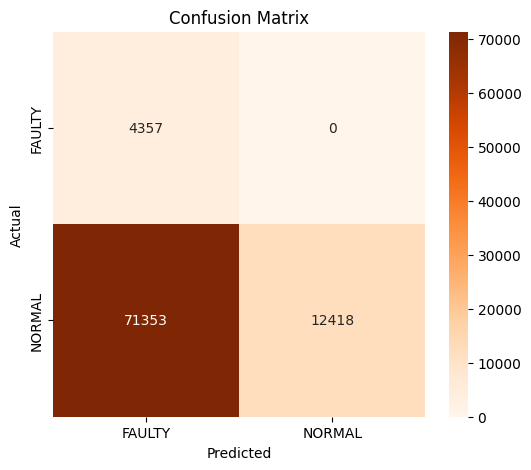

In [320]:
# Classification report with precision, recall, f1-score
print(classification_report(y_test_encoded, y_pred_encoded))


# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test_encoded, y_pred_encoded)

# Plot confusion matrix using seaborn heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Oranges", xticklabels=['FAULTY', 'NORMAL'], yticklabels=['FAULTY', 'NORMAL'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



Interpretation of Results:
Class Imbalance: There's a strong class imbalance between NORMAL and FAULTY, as indicated by the large difference in support (number of samples). The model is biased towards the majority class (NORMAL).

Faulty Detection: The model fails to detect FAULTY instances, which could be critical in some applications (e.g., defect detection). The precision, recall, and F1 score for FAULTY are all 0.

Model Tuning: You might need to address the class imbalance to improve the performance on FAULTY instances. Some potential strategies include:

Oversampling or undersampling the minority class.

Using class weights to give more importance to the FAULTY class during training.

Trying other models or algorithms that are more robust to imbalanced data (e.g., random forest, XGBoost).

Conclusion:
The model is performing well on NORMAL instances, but it's not detecting FAULTY instances at all.

The accuracy looks good overall, but the model is not performing well on the minority class (FAULTY).

To improve, you'll likely need to balance the classes better or tune the model to focus more on detecting FAULTY instances.

In [321]:
# # Calculate precision-recall curve
# precision, recall, _ = precision_recall_curve(y_test_encoded, y_pred_encoded)

# # Plot the precision-recall curve
# plt.figure(figsize=(6, 5))
# plt.plot(recall, precision, marker='.')
# plt.title('Precision-Recall Curve')
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.grid(True)
# plt.show()

In [322]:
# # function used in class to find the best labels in an unsupervised model

# def label_permute_compare(y,y_pred, n=3):
#     """A helper function to find the best label - number combo """
#     results = pd.DataFrame(y)
#     perms = list(itertools.permutations([0, 1, 2]))      #create permutation list
#     best_labels = []
#     best_acc = 0 
#     current = {}
#     labels = ['NORMAL', 'BROKEN', 'RECOVERING']
#     for perm in perms:
#         for i in range(n):
#             current[labels[i]] = perm[i]
#             if len(current) == 3:
#                 conditions = [
#                     (y['machine_status'] == current['NORMAL']),
#                     (y['machine_status'] == current['BROKEN']),
#                     (y['machine_status'] == current['RECOVERING'])]
#                 results['test'] = results['machine_status'].map(current)
#                 current_accuracy = accuracy_score(results['test'], y_pred)
#                 if current_accuracy > best_acc: 
#                     best_acc = current_accuracy
#                     best_labels = perm
#                     results['best'] = results['test']
#     return best_labels, best_acc

# # predict the testing set using a BGM model 
# best_labels, best_acc = label_permute_compare(y_true, y_pred, n=3)
# print('Test Accuracy:', round(best_acc,4), '\n', 'Best labels:', best_labels)

# # Look at precision and recall 
# precision, recall, fscore, support = precision_recall_fscore_support(y_true['best'], y_pred, zero_division=1, average = 'micro')
# print('Test Precision:', round(precision,4))
# print('Test Recall:   ', round(recall, 4))

# # create visual confusion matrix
# ConfusionMatrixDisplay.from_predictions(y_true['best'], y_pred, cmap='Oranges')
# plt.title('Confusion Matrix')
# plt.show();
# print(y_true['machine_status'].value_counts())


In [323]:
# TIME_STEPS = 650  # Adjusted from 500

# def create_sequence_generator(values, time_steps=TIME_STEPS):
#     for i in range(len(values) - time_steps + 1):
#         yield values[i : (i + time_steps)]

# # Convert generator to iterable (without excessive RAM usage)
# x_train_gen = create_sequence_generator(X_train_PCA, TIME_STEPS)
# x_test_gen = create_sequence_generator(X_test_PCA, TIME_STEPS)

# # Example: Process one batch at a time (use in training loop)
# for batch in x_train_gen:
#     print(batch.shape)  # Just to verify output
#     break  # Stop after one batch (otherwise, it runs indefinitely)

# x_train = np.array([X_train_PCA[i : i + TIME_STEPS] for i in range(len(X_train_PCA) - TIME_STEPS + 1)])
# # x_test = np.array([X_test_PCA[i : i + TIME_STEPS] for i in range(len(X_test_PCA) - TIME_STEPS + 1)])


In [324]:
# print(x_train.shape)

In [325]:
# from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# # Hyperparameters
# BATCH_SIZE = 256
# LEARNING_RATE = 1e-3  # Start higher and let ReduceLROnPlateau adjust it

# # Model Definition
# model = keras.Sequential([
#     layers.Input(shape=(TIME_STEPS, x_train.shape[2])),

#     # Encoder
#     layers.Conv1D(filters=32, kernel_size=7, padding="same", strides=2, activation="relu"),
#     layers.BatchNormalization(),
#     layers.Dropout(rate=0.2),

#     layers.Conv1D(filters=64, kernel_size=5, padding="same", strides=2, activation="relu"),
#     layers.BatchNormalization(),

#     layers.Conv1D(filters=128, kernel_size=3, padding="same", strides=2, activation="relu"),
#     layers.BatchNormalization(),

#     # Decoder (Use UpSampling1D + Conv1D instead of Conv1DTranspose)
#     layers.UpSampling1D(size=2),
#     layers.Conv1D(filters=64, kernel_size=3, padding="same", activation="relu"),
#     layers.BatchNormalization(),

#     layers.UpSampling1D(size=2),
#     layers.Conv1D(filters=32, kernel_size=5, padding="same", activation="relu"),
#     layers.BatchNormalization(),
#     layers.Dropout(rate=0.2),

#     layers.UpSampling1D(size=2),
#     layers.Conv1D(filters=x_train.shape[2], kernel_size=7, padding="same", activation="relu"),

#     # Final output layer
#     layers.Conv1D(filters=x_train.shape[2], kernel_size=1, padding="same"),

#     # 🛠 Fix: Cropping to match original size if necessary
#     layers.Cropping1D(cropping=(3, 0))  # Adjust cropping value as needed
# ])

# # Learning Rate Decay
# lr_scheduler = ReduceLROnPlateau(
#     monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, mode="min"
# )

# # Compile Model
# optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
# model.compile(optimizer=optimizer, loss="mse")

# # Print model summary
# model.summary()


In [326]:
# # Callbacks: EarlyStopping + ReduceLROnPlateau
# callbacks = [
#     EarlyStopping(monitor="val_loss", patience=5, mode="min"),
#     lr_scheduler
# ]

# # Train the model
# history = model.fit(
#     x_train, x_train,  # Autoencoder: input = output
#     epochs=50,
#     batch_size=BATCH_SIZE,
#     validation_split=0.1,
#     callbacks=callbacks
# )

In [327]:
# TIME_STEPS = 1400  # Now using full-day sequences

# # Function to create sequences
# def create_sequences(values, time_steps=TIME_STEPS):
#     output = []
#     for i in range(len(values) - time_steps + 1):
#         output.append(values[i : (i + time_steps)])
#     return np.stack(output)

# # Creating sequences for full-day analysis
# x_train = create_sequences(X_train_PCA, TIME_STEPS)
# x_test = create_sequences(X_test_PCA, TIME_STEPS)

# print("Training input shape: ", x_train.shape)
# print("Test input shape: ", x_test.shape)

In [328]:
# import numpy as np
# import pandas as pd
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA

# TIME_STEPS = 1400  # Now using full-day sequences

# # Function to create sequences
# def create_sequences(values, time_steps=TIME_STEPS):
#     output = []
#     for i in range(len(values) - time_steps + 1):
#         output.append(values[i : (i + time_steps)])
#     return np.stack(output)

# # Load and preprocess data
# df = pd.read_csv("C:/Users/andsa/Documents/ML/MLing/dataset/sensor.csv")

# df["timestamp"] = pd.to_datetime(df["timestamp"])
# df.drop(columns=["num"], axis=1, inplace=True)
# df.drop(columns=["sensor_15", "sensor_50", "sensor_51"], axis=1, inplace=True)
# df.fillna(method='ffill', inplace=True)

# # Splitting into train and test sets (60% train, 40% test)
# last_40percent = round(len(df) - len(df)*.4)
# train = df.iloc[:last_40percent, :]
# test = df.iloc[last_40percent:, :]

# # Selecting features (excluding timestamp and labels)
# X_train = train.iloc[:, 1:-1].copy()
# X_test = test.iloc[:, 1:-1].copy()

# # Standardizing the data
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # Applying PCA
# pca = PCA(n_components=0.95, svd_solver='full', random_state=42)
# X_train_PCA = pca.fit_transform(X_train_scaled)
# X_test_PCA = pca.transform(X_test_scaled)

# # Creating sequences for full-day analysis
# x_train = create_sequences(X_train_PCA, TIME_STEPS)
# x_test = create_sequences(X_test_PCA, TIME_STEPS)

# print("Training input shape: ", x_train.shape)
# print("Test input shape: ", x_test.shape)


In [329]:
# df = pd.read_csv("C:/Users/andsa/Documents/ML/MLing/dataset/sensor.csv")
# # df["timestamp"] = pd.to_datetime(df["timestamp"])
# # df.info()
# # df.drop(columns=["num", "timestamp", "machine_status"], axis=1,  inplace=True)

# df.drop(columns=["num", "timestamp"], axis=1,  inplace=True)
# df.drop(columns=["sensor_15", "sensor_50", "sensor_51"], axis=1,  inplace=True)
# df.columns.str.strip()
# df.fillna(method='ffill', inplace=True)



In [330]:
# # for items in df["machine_status"]:
# #     if items == "NORMAL":
# #         print(items)

# def find_occurance(df, column, token):
#     num = 0
#     for status in df[column]:
#         if status == token:
#             num += 1
#     return num
# # num_of_broken = find_occurance(df, 'machine_status', 'BROKEN')
# # print(f'The number of BROKEN occurances are: {num_of_broken}')


# def return_columns_with_lots_of_NAN(df, limit):
#     columns_to_remove = ''

#     for column in df:
#         column_length = len(df[column])
#         nan = df[column].isna().sum()

#         fraction = nan / column_length

#         if fraction >= limit:
#             columns_to_remove += (column + ', ')
#     return columns_to_remove 
# # nan_string = return_columns_with_lots_of_NAN(df, 0.05)
# # print(f'Columns with more than the limit of NAN values: {nan_string}')

# # dropping columns with high linear correlation 
# df.drop(columns=["sensor_19", "sensor_18", "sensor_21", "sensor_23", "sensor_24"], axis=1,  inplace=True)

# # https://www.geeksforgeeks.org/principal-component-analysis-pca/

In [331]:
# df.drop(columns=["timestamp"], axis=1,  inplace=True)
# # assigning the X and y values 
# X = df.drop(['machine_status'], axis = 1)
# y = df[['machine_status']]

# # importing a splitter for the data 
# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.6, random_state=RANDOMSTATE)
# # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = pd.qcut(y, q = 5, duplicates='drop'))

# # Scaling the data 
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

In [332]:
# print(df.isnull().sum())
# df.head()
# df.describe()

# Select the first 3 columns, excluding "num" and "timestamp"
# columns_to_plot = df.columns[:5]  # Get the first 3 columns

# Loop over the selected columns
# for column in columns_to_plot:
#     if column == "num" or column == "timestamp":
#         continue  # Skip "num" and "timestamp"
    
#     plt.figure(figsize=(22, 1), dpi=600)
#     plt.title(column)
#     plt.plot(df["num"], df[column])  # Plot against the "num" column
#     plt.show()

In [333]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.preprocessing import StandardScaler
# from keras.models import Sequential
# from keras.layers import Dense
# from sklearn.metrics import mean_squared_error
# import seaborn as sns

# # Step 1: Load the data
# df = pd.read_csv("C:/Users/andsa/Documents/ML/MLing/dataset/sensor.csv")

# df.drop(columns=["machine_status", "sensor_15"], axis=1,  inplace=True)
# df.fillna(method='ffill', inplace=True)
# df.columns = df.columns.str.strip()

# # Convert 'timestamp' to datetime and remove it
# df["timestamp"] = pd.to_datetime(df["timestamp"])
# df = df.drop(columns=["timestamp"])

# # Standardize the data
# scaler = StandardScaler()
# data_scaled = scaler.fit_transform(df)

# # Step 2: Build the Autoencoder Model
# # Define the autoencoder model architecture
# autoencoder = Sequential()
# autoencoder.add(Dense(64, input_dim=data_scaled.shape[1], activation='relu'))
# autoencoder.add(Dense(32, activation='relu'))
# autoencoder.add(Dense(16, activation='relu'))
# autoencoder.add(Dense(32, activation='relu'))
# autoencoder.add(Dense(64, activation='relu'))
# autoencoder.add(Dense(data_scaled.shape[1], activation='sigmoid'))  # Output layer

# # Compile the model
# autoencoder.compile(optimizer='adam', loss='mean_squared_error')

# # Step 3: Train the Autoencoder
# # Train the autoencoder on the normal data (since it's unsupervised, we don't need labels)
# autoencoder.fit(data_scaled, data_scaled, epochs=50, batch_size=256, shuffle=True)

# # Step 4: Use the trained model to detect anomalies
# # Compute the reconstruction error for each data point
# reconstructed = autoencoder.predict(data_scaled)
# reconstruction_error = mean_squared_error(data_scaled, reconstructed, multioutput='raw_values')

# # Set a threshold for anomaly detection (e.g., based on the distribution of the error)
# threshold = np.percentile(reconstruction_error, 95)  # 95th percentile as the threshold for anomaly

# # Mark anomalies where the reconstruction error exceeds the threshold
# anomalies = reconstruction_error > threshold

# # Step 5: Visualize the results
# plt.figure(figsize=(10,6))
# plt.plot(df.index, reconstruction_error, label='Reconstruction Error')
# plt.axhline(y=threshold, color='r', linestyle='--', label='Anomaly Threshold')
# plt.scatter(df.index[anomalies], reconstruction_error[anomalies], color='r', label='Anomalies')
# plt.title('Reconstruction Error and Anomalies')
# plt.xlabel('Index')
# plt.ylabel('Reconstruction Error')
# plt.legend()
# plt.show()

# # Step 6: Output the anomalies
# df['anomaly'] = anomalies
# print(df[df['anomaly'] == True])  # Display rows identified as anomalies
